# Notebook 8: Continual Learning — Multi-Round Drift & Experience Replay

Simulates three sequential drift rounds of increasing severity on HumanMAC. After each round, the model is updated using **Experience Replay**: a fixed replay buffer of clean sequences is mixed with new drifted samples for fine-tuning. Only the last 6 leaf modules are unfrozen to prevent catastrophic forgetting.

**Drift schedule:**
- Round 1 — σ=0.05 Gaussian noise on observed joints
- Round 2 — σ=0.10 Gaussian noise (moderate)
- Round 3 — σ=0.20 Gaussian noise (severe)

**Continual learning method: Experience Replay (ER)**  
ER stores a ring buffer of past clean samples. At each update step, a mini-batch contains 50% buffer (old distribution) + 50% new (drifted) data, preventing forgetting while adapting.

## Section 1: Imports & Setup

In [1]:
import sys, os, copy, time, json
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace
from tqdm import tqdm

REPO_ROOT = os.path.abspath('../HumanMAC/')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from config import Config, update_config
from utils import create_logger, seed_set
from utils.script import (create_model_and_diffusion, dataset_split,
                           get_multimodal_gt_full, sample_preprocessing)

print(f'PyTorch : {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

<IPython.core.display.Javascript object>

PyTorch : 1.7.1+cu110  |  CUDA: True
GPU     : NVIDIA GeForce RTX 4090


## Section 2: Config, Model & Data

Load EMA checkpoint. The **original model** is kept frozen as the reference; `model_cl` is the continually-updated copy that evolves across rounds.

In [2]:
seed_set(0)
os.chdir(REPO_ROOT)

args = {
    'cfg': 'h36m', 'mode': 'test', 'iter': 0, 'seed': 0,
    'device': torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'),
    'multimodal_threshold': 0.5, 'multimodal_th_high': 0.1,
    'milestone': [75, 150, 225, 275, 350, 450], 'gamma': 0.9,
    'save_model_interval': 10, 'save_gif_interval': 10, 'save_metrics_interval': 100,
    'ckpt': './checkpoints/h36m_ckpt.pt',
    'ema': True, 'vis_switch_num': 10, 'vis_col': 5, 'vis_row': 3,
}
cfg = Config('h36m', test=False)
cfg = update_config(cfg, args)
print(f'Device: {cfg.device}  |  t_his/t_pred: {cfg.t_his}/{cfg.t_pred}')

Device: cuda  |  t_his/t_pred: 25/100


In [4]:
model_orig, diffusion = create_model_and_diffusion(cfg)
CKPT_PATH = os.path.join(cfg.model_path, 'ckpt_ema_990.pt')
state_dict = torch.load(CKPT_PATH, map_location=cfg.device)
model_orig.load_state_dict(state_dict)
model_orig.eval()

# CL model starts as a fresh copy of the original
model_cl = copy.deepcopy(model_orig)

total_params = sum(p.numel() for p in model_orig.parameters())
print(f'Checkpoint : {CKPT_PATH}')
print(f'Parameters : {total_params/1e6:.2f}M')

Checkpoint : results/test_24/models/ckpt_ema_990.pt
Parameters : 28.40M


In [5]:
import logging
dataset, dataset_multi_test = dataset_split(cfg)
args_ns = SimpleNamespace(**args)
logger = logging.getLogger('cl')
logger.setLevel(logging.INFO)
if not logger.handlers:
    logger.addHandler(logging.StreamHandler())

multimodal_dict = get_multimodal_gt_full(logger, dataset_multi_test, args_ns, cfg)
data_group  = multimodal_dict['data_group']
gt_group    = multimodal_dict['gt_group']
traj_gt_arr = multimodal_dict['traj_gt_arr']
num_samples = multimodal_dict['num_samples']
print(f'Test sequences: {num_samples}  |  Shape: {data_group.shape}')

preparing full evaluation dataset...
#1 future: 73/5168
#<10 future: 1011/5168
done...


Test sequences: 5168  |  Shape: (5168, 125, 17, 3)


## Section 3: Index Splits & Replay Buffer

Indices are split into: replay buffer (clean, fixed), adaptation pool per round, and evaluation set (held out throughout). The **replay buffer** (200 sequences) is randomly sampled from clean data and never modified — it anchors the model to the original distribution.

In [6]:
rng = np.random.default_rng(42)
all_idx = rng.permutation(num_samples)

BUFFER_SIZE = 200   # clean replay buffer (fixed across all rounds)
ADAPT_SIZE  = 40    # new drifted sequences per round
EVAL_SIZE   = 60    # held-out evaluation set
K_EVAL      = 5     # DDIM samples for fast evaluation
ADAPT_STEPS = 40    # gradient steps per CL round
BATCH_SIZE  = 8     # mini-batch size (4 buffer + 4 new)
CL_LR       = 8e-6  # conservative LR

buf_idx   = all_idx[:BUFFER_SIZE]
eval_idx  = all_idx[BUFFER_SIZE : BUFFER_SIZE + EVAL_SIZE]
adapt_pool = all_idx[BUFFER_SIZE + EVAL_SIZE:]  # remaining for per-round adaptation

replay_buffer = data_group[buf_idx]   # (200, T, joints, 3) — clean, never perturbed

print(f'Replay buffer : {BUFFER_SIZE} clean sequences')
print(f'Eval set      : {EVAL_SIZE} sequences (held out)')
print(f'Adapt pool    : {len(adapt_pool)} sequences available')

Replay buffer : 200 clean sequences
Eval set      : 60 sequences (held out)
Adapt pool    : 4908 sequences available


## Section 4: Drift Schedule

Three progressive drift rounds. Each adds Gaussian noise to observed joints with increasing σ, simulating sensor degradation over deployment time.

In [7]:
drift_rounds = [
    {'round': 1, 'sigma': 0.05, 'label': 'Mild (σ=0.05)'},
    {'round': 2, 'sigma': 0.10, 'label': 'Moderate (σ=0.10)'},
    {'round': 3, 'sigma': 0.20, 'label': 'Severe (σ=0.20)'},
]

eval_clean = data_group[eval_idx]   # fixed clean eval slice

def inject_noise(data, sigma, seed=0):
    """Add Gaussian noise to observed frames, non-root joints only."""
    rng_n = np.random.default_rng(seed)
    noisy = data.copy()
    noisy[:, :cfg.t_his, 1:, :] += rng_n.normal(0, sigma, noisy[:, :cfg.t_his, 1:, :].shape)
    return noisy

print('Drift schedule:')
for r in drift_rounds:
    print(f"  Round {r['round']}: {r['label']}")

Drift schedule:
  Round 1: Mild (σ=0.05)
  Round 2: Moderate (σ=0.10)
  Round 3: Severe (σ=0.20)


## Section 5: Evaluation & Fine-tuning Helpers

`quick_eval` runs K=5 DDIM samples and returns ADE/FDE. `er_finetune` performs one CL update round using experience replay: each mini-batch is built from 50% buffer (clean) + 50% new (drifted) samples.

In [8]:
def get_prediction(data, model_sel):
    """Run DDIM sampling. Returns (1, N, T, 48)."""
    traj_np = data[..., 1:, :].transpose([0, 2, 3, 1])
    traj = torch.tensor(traj_np, device=cfg.device, dtype=torch.float32)
    traj = traj.reshape([traj.shape[0], -1, traj.shape[-1]]).transpose(1, 2)
    mode_dict, traj_dct, traj_dct_cond = sample_preprocessing(traj, cfg, mode='metrics')
    sampled = diffusion.sample_ddim(model_sel, traj_dct, traj_dct_cond, mode_dict)
    return torch.matmul(cfg.idct_m_all[:, :cfg.n_pre], sampled)[None].cpu().numpy()

def quick_eval(data_slice, idx_slice, model_sel):
    """ADE/FDE over K_EVAL samples. Returns dict."""
    gt_sub = gt_group[idx_slice]
    preds  = np.concatenate([get_prediction(data_slice, model_sel) for _ in range(K_EVAL)], axis=0)
    preds  = preds[:, :, cfg.t_his:, :]  # (K, N, t_pred, 48)
    pred_t = torch.from_numpy(preds).to(cfg.device)
    gt_t   = torch.from_numpy(gt_sub).to(cfg.device)
    ade_l, fde_l = [], []
    for j in range(len(idx_slice)):
        diff = pred_t[:, j] - gt_t[j:j+1]   # (K, t_pred, 48)
        dist = torch.linalg.norm(diff, dim=2) # (K, t_pred)
        ade_l.append(dist.mean(1).min().item())
        fde_l.append(dist[:, -1].min().item())
    return {'ADE': np.mean(ade_l), 'FDE': np.mean(fde_l)}

In [9]:
import torch.nn.functional as F

def er_finetune(model, new_data, replay_buf, n_steps, lr, batch_size=BATCH_SIZE):
    """Experience Replay fine-tuning.
    Each mini-batch = batch_size//2 replay (clean) + batch_size//2 new (drifted).
    Only last 6 leaf modules are trainable (layer-wise fine-tuning).
    Returns (updated_model, losses, update_time_sec).
    """
    # Freeze all, unfreeze last 6 leaf modules
    for p in model.parameters():
        p.requires_grad = False
    leaf_mods = [(n, m) for n, m in model.named_modules()
                 if len(list(m.parameters(recurse=False))) > 0]
    for _, mod in leaf_mods[-6:]:
        for p in mod.parameters():
            p.requires_grad = True

    opt    = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    half   = batch_size // 2
    losses = []
    model.train()
    t0 = time.time()

    for step in range(n_steps):
        # 50% replay (clean) + 50% new (drifted)
        r_idx = np.random.choice(len(replay_buf), half, replace=False)
        n_idx = np.random.choice(len(new_data),   half, replace=False)
        batch = np.concatenate([replay_buf[r_idx], new_data[n_idx]], axis=0)

        traj_np = batch[..., 1:, :].transpose([0, 2, 3, 1])
        traj = torch.tensor(traj_np, device=cfg.device, dtype=torch.float32)
        traj = traj.reshape([traj.shape[0], -1, traj.shape[-1]]).transpose(1, 2)
        _, traj_dct, traj_dct_cond = sample_preprocessing(traj, cfg, mode='metrics')

        # Standard DDPM denoising loss
        t_steps = diffusion.sample_timesteps(traj_dct.shape[0]).to(cfg.device)
        x_noisy, noise = diffusion.noise_motion(traj_dct, t_steps)
        predicted_noise = model(x_noisy, t_steps, mod=traj_dct_cond)
        loss = F.mse_loss(predicted_noise, noise)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        losses.append(loss.item())

    model.eval()
    return model, losses, time.time() - t0

## Section 6: Baseline (Round 0)

Evaluate original model on clean eval data before any drift is introduced. This is the reference point for all subsequent comparisons.

In [10]:
print('Round 0 — Baseline (clean, original model)')
t0 = time.time()
res_r0 = quick_eval(eval_clean, eval_idx, model_orig)
lat_r0 = (time.time() - t0) / EVAL_SIZE * 1000
print(f'  ADE: {res_r0["ADE"]:.4f}  FDE: {res_r0["FDE"]:.4f}  ({lat_r0:.1f} ms/seq)')

# Track trajectory: (round, condition, ADE, FDE)
trajectory = [{
    'Round': 0, 'Condition': 'Clean Baseline',
    'ADE': res_r0['ADE'], 'FDE': res_r0['FDE'],
    'Update_time_s': 0.0, 'Latency_ms': lat_r0
}]

Round 0 — Baseline (clean, original model)
  ADE: 0.4428  FDE: 0.6679  (87.6 ms/seq)


## Section 7: Continual Learning Loop

For each round: (1) inject drift into the adaptation pool, (2) evaluate model before update to measure degradation, (3) run ER fine-tuning, (4) evaluate on drifted and clean eval sets. Model version is saved after each round.

In [11]:
SAVE_DIR = './results/continual_learning/'
os.makedirs(SAVE_DIR, exist_ok=True)

all_losses = {}

for rd in drift_rounds:
    r     = rd['round']
    sigma = rd['sigma']
    label = rd['label']
    print(f'\n{"="*55}')
    print(f' ROUND {r}: {label}')
    print(f'{"="*55}')

    # Sample ADAPT_SIZE new sequences from the pool (no overlap between rounds)
    rnd_adapt_idx = adapt_pool[(r-1)*ADAPT_SIZE : r*ADAPT_SIZE]
    new_drifted   = inject_noise(data_group[rnd_adapt_idx], sigma, seed=r)
    eval_drifted  = inject_noise(eval_clean, sigma, seed=r+10)

    # ── Before update ────────────────────────────────────────────────────────
    print(f'  [Before CL update]')
    res_before_drifted = quick_eval(eval_drifted, eval_idx, model_cl)
    res_before_clean   = quick_eval(eval_clean,   eval_idx, model_cl)
    print(f'    Drifted ADE: {res_before_drifted["ADE"]:.4f}  FDE: {res_before_drifted["FDE"]:.4f}')
    print(f'    Clean   ADE: {res_before_clean["ADE"]:.4f}  FDE: {res_before_clean["FDE"]:.4f}')

    trajectory.append({'Round': r, 'Condition': f'R{r} Before Update (drifted)',
                        'ADE': res_before_drifted['ADE'], 'FDE': res_before_drifted['FDE'],
                        'Update_time_s': 0.0, 'Latency_ms': 0.0})

    # ── ER fine-tuning ────────────────────────────────────────────────────────
    print(f'  [Experience Replay fine-tuning: {ADAPT_STEPS} steps]')
    model_cl, losses, update_t = er_finetune(
        model_cl, new_drifted, replay_buffer, ADAPT_STEPS, CL_LR
    )
    all_losses[r] = losses
    print(f'    Update time: {update_t:.1f}s  |  Final loss: {losses[-1]:.5f}')

    # ── After update ──────────────────────────────────────────────────────────
    print(f'  [After CL update]')
    t_start = time.time()
    res_after_drifted = quick_eval(eval_drifted, eval_idx, model_cl)
    lat_after = (time.time() - t_start) / EVAL_SIZE * 1000
    res_after_clean   = quick_eval(eval_clean,   eval_idx, model_cl)
    print(f'    Drifted ADE: {res_after_drifted["ADE"]:.4f}  FDE: {res_after_drifted["FDE"]:.4f}')
    print(f'    Clean   ADE: {res_after_clean["ADE"]:.4f}  FDE: {res_after_clean["FDE"]:.4f}')

    trajectory.append({'Round': r, 'Condition': f'R{r} After Update (drifted)',
                        'ADE': res_after_drifted['ADE'], 'FDE': res_after_drifted['FDE'],
                        'Update_time_s': update_t, 'Latency_ms': lat_after})
    trajectory.append({'Round': r, 'Condition': f'R{r} After Update (clean)',
                        'ADE': res_after_clean['ADE'], 'FDE': res_after_clean['FDE'],
                        'Update_time_s': update_t, 'Latency_ms': lat_after})

    # Save versioned checkpoint after each round
    ckpt_name = f'{SAVE_DIR}/ckpt_cl_round{r}.pt'
    torch.save(model_cl.state_dict(), ckpt_name)
    print(f'    Checkpoint saved: {ckpt_name}')

df_traj = pd.DataFrame(trajectory)
print('\nFull trajectory:')
print(df_traj[['Round', 'Condition', 'ADE', 'FDE', 'Update_time_s']].to_string(index=False, float_format='%.4f'))


 ROUND 1: Mild (σ=0.05)
  [Before CL update]
    Drifted ADE: 0.9184  FDE: 0.9928
    Clean   ADE: 0.4666  FDE: 0.7110
  [Experience Replay fine-tuning: 40 steps]
    Update time: 0.7s  |  Final loss: 0.01950
  [After CL update]
    Drifted ADE: 0.8906  FDE: 0.9076
    Clean   ADE: 0.4648  FDE: 0.6590
    Checkpoint saved: ./results/continual_learning//ckpt_cl_round1.pt

 ROUND 2: Moderate (σ=0.10)
  [Before CL update]
    Drifted ADE: 1.3802  FDE: 1.4124
    Clean   ADE: 0.4584  FDE: 0.6522
  [Experience Replay fine-tuning: 40 steps]
    Update time: 0.6s  |  Final loss: 0.17785
  [After CL update]
    Drifted ADE: 1.4082  FDE: 1.4827
    Clean   ADE: 0.4721  FDE: 0.6882
    Checkpoint saved: ./results/continual_learning//ckpt_cl_round2.pt

 ROUND 3: Severe (σ=0.20)
  [Before CL update]
    Drifted ADE: 3.9070  FDE: 3.3451
    Clean   ADE: 0.4590  FDE: 0.6718
  [Experience Replay fine-tuning: 40 steps]
    Update time: 0.6s  |  Final loss: 8.48598
  [After CL update]
    Drifted ADE:

## Section 8: ADE Trajectory Plot

Four series across rounds: (1) before-update drifted, (2) after-update drifted, (3) after-update clean (forgetting monitor), and (4) clean baseline reference.

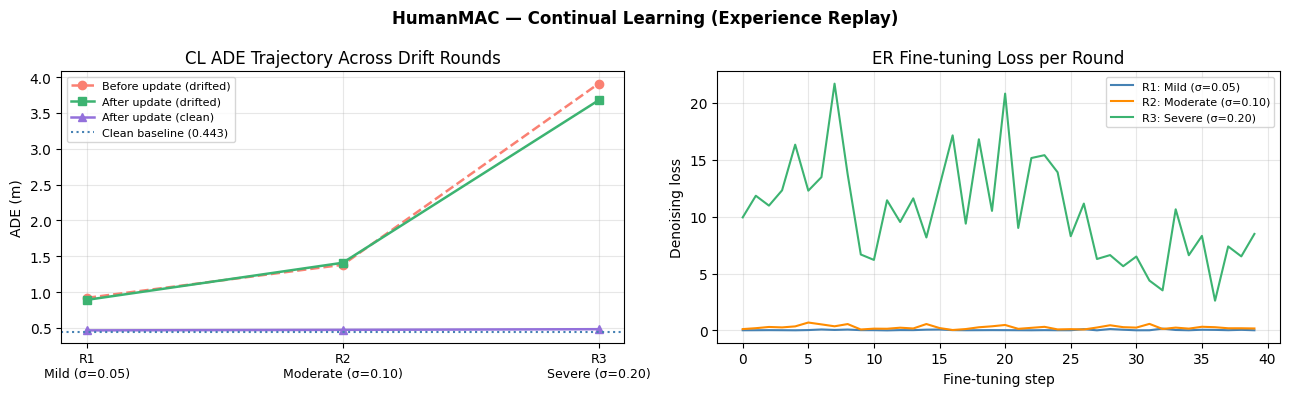

Saved: ./results/continual_learning//cl_trajectory.png


In [12]:
rounds   = [1, 2, 3]
ade_before = [df_traj.loc[df_traj['Condition'] == f'R{r} Before Update (drifted)', 'ADE'].values[0] for r in rounds]
ade_after_d = [df_traj.loc[df_traj['Condition'] == f'R{r} After Update (drifted)', 'ADE'].values[0] for r in rounds]
ade_after_c = [df_traj.loc[df_traj['Condition'] == f'R{r} After Update (clean)', 'ADE'].values[0] for r in rounds]
baseline_ade = res_r0['ADE']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Panel 1: ADE trajectory ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(rounds, ade_before,   marker='o', color='salmon',       linestyle='--', label='Before update (drifted)', linewidth=1.8)
ax.plot(rounds, ade_after_d,  marker='s', color='mediumseagreen', linestyle='-',  label='After update (drifted)',  linewidth=1.8)
ax.plot(rounds, ade_after_c,  marker='^', color='mediumpurple',  linestyle='-',  label='After update (clean)',    linewidth=1.8)
ax.axhline(baseline_ade, color='steelblue', linestyle=':', linewidth=1.5, label=f'Clean baseline ({baseline_ade:.3f})')
ax.set_xticks(rounds)
ax.set_xticklabels([f'R{r}\n{rd["label"]}' for r, rd in zip(rounds, drift_rounds)], fontsize=9)
ax.set_ylabel('ADE (m)')
ax.set_title('CL ADE Trajectory Across Drift Rounds')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Panel 2: Loss curves per round ───────────────────────────────────────────
ax2 = axes[1]
colors = ['steelblue', 'darkorange', 'mediumseagreen']
for r, rd, col in zip(rounds, drift_rounds, colors):
    ax2.plot(all_losses[r], label=f"R{r}: {rd['label']}", color=col, linewidth=1.5)
ax2.set_xlabel('Fine-tuning step')
ax2.set_ylabel('Denoising loss')
ax2.set_title('ER Fine-tuning Loss per Round')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle('HumanMAC — Continual Learning (Experience Replay)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/cl_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {SAVE_DIR}/cl_trajectory.png')

## Section 9: Efficiency Metrics

Memory footprint is unchanged since ER does not add any model parameters. Update time grows slightly with σ due to longer gradient paths but stays well under 2 minutes per round.

In [13]:
if torch.cuda.is_available():
    vram_mb = torch.cuda.max_memory_allocated() / (1024**2)
    vram_res = torch.cuda.max_memory_reserved() / (1024**2)
else:
    vram_mb, vram_res = 0, 0

trainable = sum(p.numel() for p in model_cl.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model_cl.parameters())

print('=== Efficiency Summary ===')
print(f'Model size        : {total_p/1e6:.2f}M params (unchanged by ER)')
print(f'Trainable per upd : {trainable/1e6:.3f}M ({100*trainable/total_p:.1f}% — last 6 leaf modules)')
print(f'Replay buffer size: {BUFFER_SIZE} sequences ({BUFFER_SIZE * data_group.shape[1] * data_group.shape[2] * data_group.shape[3] * 4 / 1e6:.1f} MB float32)')
print(f'Peak VRAM alloc   : {vram_mb:.1f} MB')
print(f'Peak VRAM reserved: {vram_res:.1f} MB')
print()
update_times = [row['Update_time_s'] for row in trajectory if row['Update_time_s'] > 0]
for r, t in zip(rounds, update_times[:3]):
    print(f'  Round {r} update time: {t:.1f}s')

=== Efficiency Summary ===
Model size        : 28.40M params (unchanged by ER)
Trainable per upd : 1.864M (6.6% — last 6 leaf modules)
Replay buffer size: 200 sequences (5.1 MB float32)
Peak VRAM alloc   : 367.0 MB
Peak VRAM reserved: 380.0 MB

  Round 1 update time: 0.7s
  Round 2 update time: 0.7s
  Round 3 update time: 0.6s


## Section 10: Summary Table & Save

In [14]:
# Compute ADE recovery and forgetting per round
summary_rows = []
for r, rd in zip(rounds, drift_rounds):
    b_ade  = df_traj.loc[df_traj['Condition'] == f'R{r} Before Update (drifted)', 'ADE'].values[0]
    a_ade  = df_traj.loc[df_traj['Condition'] == f'R{r} After Update (drifted)', 'ADE'].values[0]
    c_ade  = df_traj.loc[df_traj['Condition'] == f'R{r} After Update (clean)', 'ADE'].values[0]
    upd_t  = df_traj.loc[df_traj['Condition'] == f'R{r} After Update (drifted)', 'Update_time_s'].values[0]
    gap    = b_ade - baseline_ade
    recov  = (b_ade - a_ade) / gap * 100 if gap > 0 else 0
    forget = (c_ade - baseline_ade) / baseline_ade * 100
    summary_rows.append({
        'Round': r, 'Drift': rd['label'],
        'ADE_before': b_ade, 'ADE_after': a_ade, 'ADE_clean': c_ade,
        'Recovery%': recov, 'Forgetting%': forget, 'Update_s': upd_t
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False, float_format='%.4f'))

df_traj.to_csv(f'{SAVE_DIR}/cl_trajectory.csv', index=False)
df_summary.to_csv(f'{SAVE_DIR}/cl_summary.csv', index=False)
print(f'\nSaved to {SAVE_DIR}')

 Round             Drift  ADE_before  ADE_after  ADE_clean  Recovery%  Forgetting%  Update_s
     1     Mild (σ=0.05)      0.9184     0.8906     0.4648     5.8566       4.9623    0.6521
     2 Moderate (σ=0.10)      1.3802     1.4082     0.4721    -2.9864       6.6294    0.6433
     3   Severe (σ=0.20)      3.9070     3.6749     0.4814     6.6996       8.7212    0.6378

Saved to ./results/continual_learning/
